In [66]:
import pandas as pd
import numpy as np

In [67]:
df_heart = pd.read_csv('/Users/sukitharathnayake/CodeRepo/ST4035/Data/ST 4035 Heart Data.csv', index_col=0)

In [68]:
df_heart.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [69]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 1 to 303
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
 13  AHD        303 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 35.5+ KB


In [70]:
num_cols = df_heart.select_dtypes(include=['int64','float64']).columns
cat_cols = df_heart.select_dtypes(include=['object','category']).columns

df_heart[num_cols] = df_heart[num_cols].fillna(df_heart[num_cols].median())
df_heart[cat_cols] = df_heart[cat_cols].fillna(df_heart[cat_cols].mode().iloc[0])

In [71]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 1 to 303
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         303 non-null    float64
 12  Thal       303 non-null    object 
 13  AHD        303 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 35.5+ KB


In [72]:
from sklearn.model_selection import train_test_split

X = df_heart.drop('AHD', axis=1)
y = df_heart['AHD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
# --- Encoding ---
# One-hot encode categorical features: ChestPain, Thal
X_train_enc = pd.get_dummies(X_train, columns=['ChestPain', 'Thal'], drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=['ChestPain', 'Thal'], drop_first=True)

# Align columns — ensures test set has same dummy columns as train set
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

# Label-encode the target: Yes -> 1, No -> 0
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print('Encoded feature shape:', X_train_enc.shape)
print('Target classes:', le.classes_)

Encoded feature shape: (242, 16)
Target classes: ['No' 'Yes']


In [74]:
# --- Feature Scaling (StandardScaler) ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)  # fit on train only
X_test_scaled  = scaler.transform(X_test_enc)       # transform test

print('Scaling complete. Each feature now has mean ≈ 0 and std ≈ 1 on the training set.')

Scaling complete. Each feature now has mean ≈ 0 and std ≈ 1 on the training set.


In [75]:
# --- Logistic Regression ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_enc)

y_pred = lr.predict(X_test_scaled)

print(f'Accuracy : {accuracy_score(y_test_enc, y_pred):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))
print('Confusion Matrix:')
print(confusion_matrix(y_test_enc, y_pred))

Accuracy : 0.8689

Classification Report:
              precision    recall  f1-score   support

          No       0.89      0.83      0.86        29
         Yes       0.85      0.91      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

Confusion Matrix:
[[24  5]
 [ 3 29]]


## Classification Tree
Decision trees do **not** require feature scaling, so we use the one-hot-encoded (unscaled) data directly.

In [76]:
# --- Fit Classification Tree ---
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train_enc, y_train_enc)

y_pred_dt = dt.predict(X_test_enc)

print(f'Decision Tree Accuracy : {accuracy_score(y_test_enc, y_pred_dt):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test_enc, y_pred_dt, target_names=le.classes_))

Decision Tree Accuracy : 0.8033

Classification Report:
              precision    recall  f1-score   support

          No       0.72      0.97      0.82        29
         Yes       0.95      0.66      0.78        32

    accuracy                           0.80        61
   macro avg       0.84      0.81      0.80        61
weighted avg       0.84      0.80      0.80        61



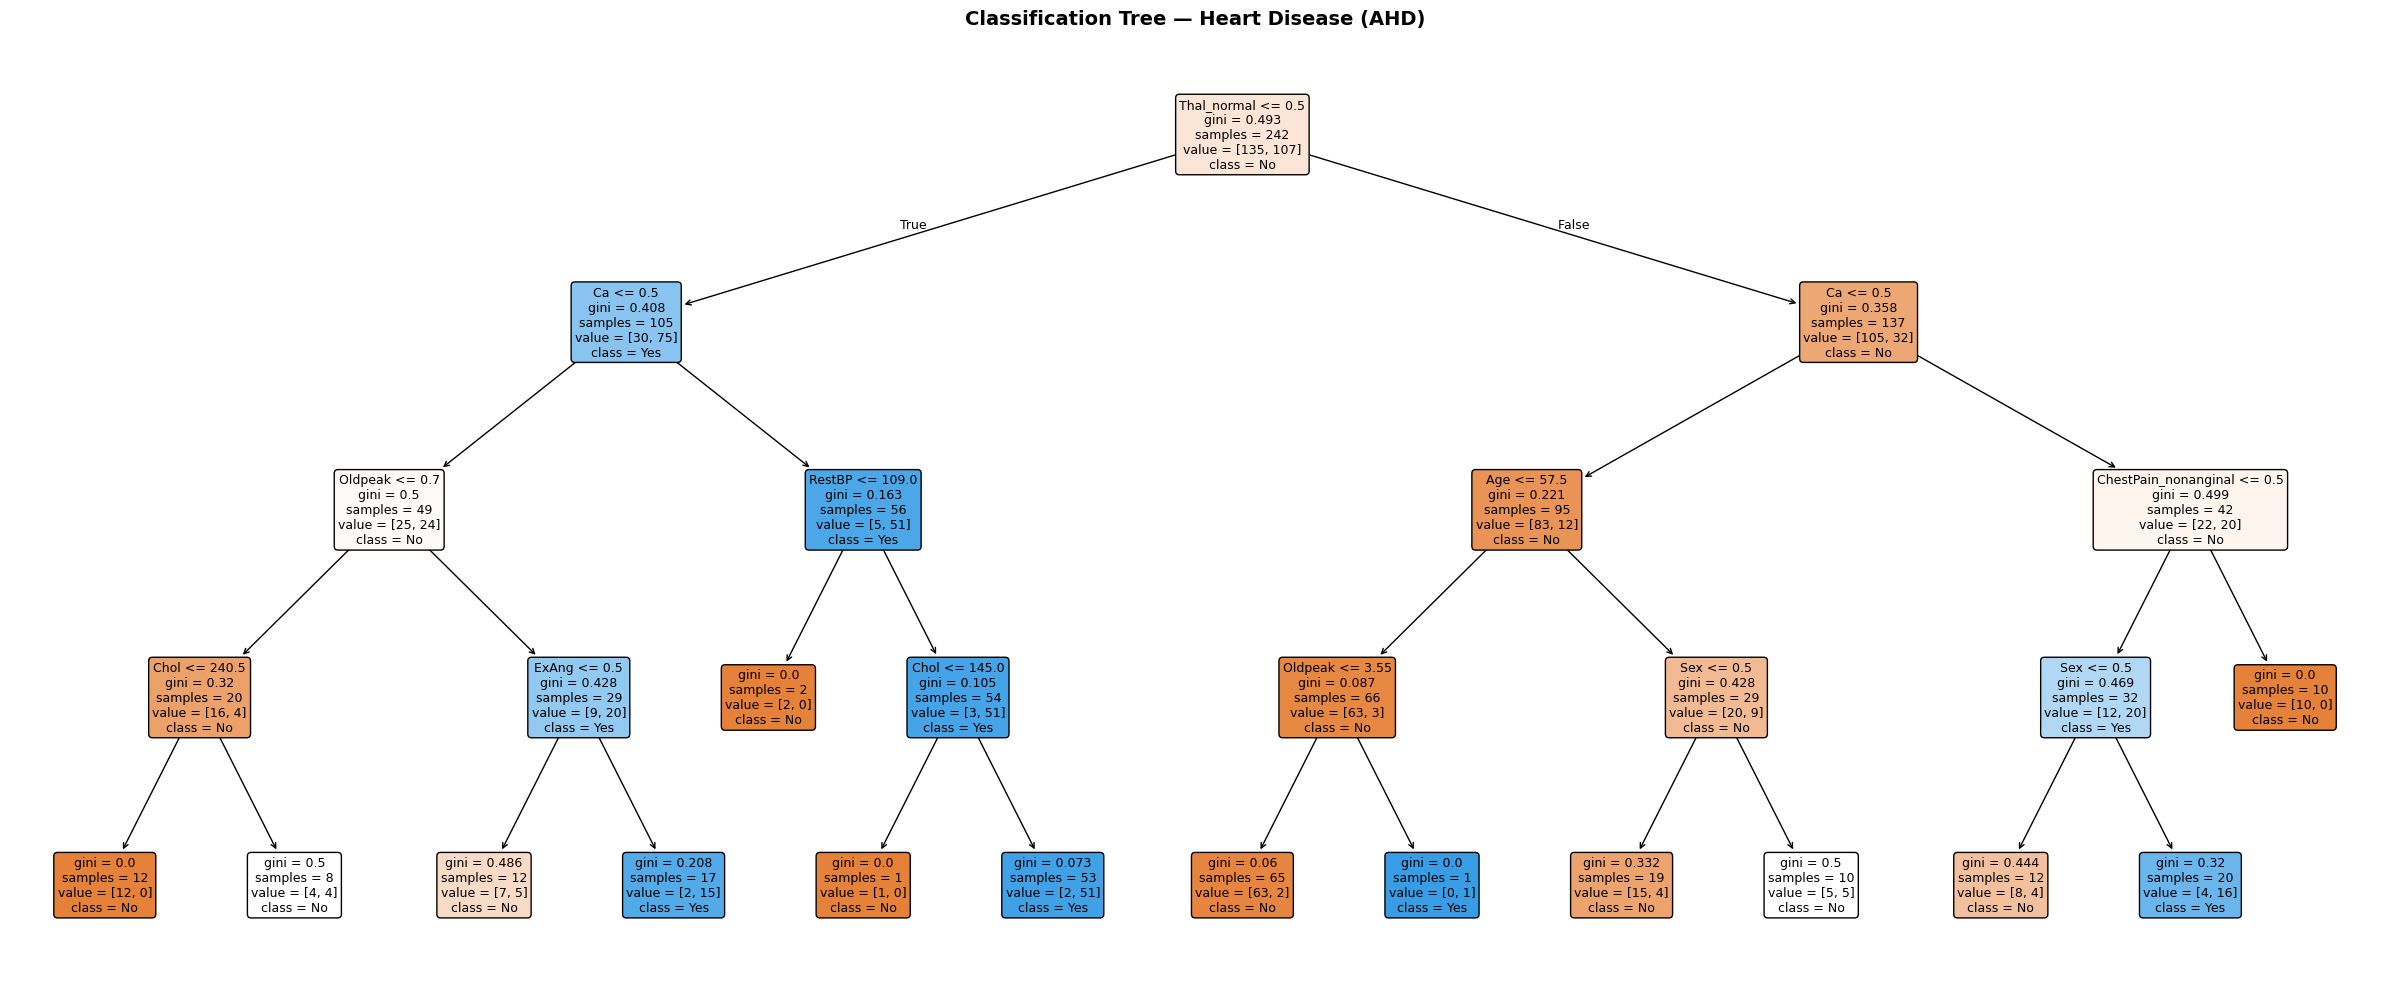

In [77]:
# --- Plot the Decision Tree ---
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    dt,
    feature_names=X_train_enc.columns.tolist(),
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Classification Tree — Heart Disease (AHD)', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

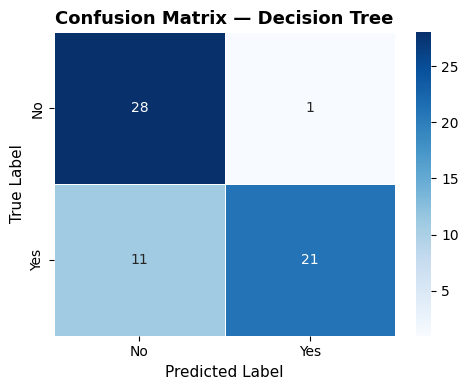

True Negatives  (No  → No ) : 28
False Positives (No  → Yes) : 1
False Negatives (Yes → No ) : 11
True Positives  (Yes → Yes) : 21

Overall Accuracy            : 0.8033


In [78]:
# --- Confusion Matrix Heatmap ---
import seaborn as sns

cm = confusion_matrix(y_test_enc, y_pred_dt)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.5,
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Confusion Matrix — Decision Tree', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (No  → No ) : {tn}')
print(f'False Positives (No  → Yes) : {fp}')
print(f'False Negatives (Yes → No ) : {fn}')
print(f'True Positives  (Yes → Yes) : {tp}')
print(f'\nOverall Accuracy            : {accuracy_score(y_test_enc, y_pred_dt):.4f}')

## Random Forest
We set `max_features = X_train_enc.shape[1]` (all predictors at every split), which is the Python equivalent of `randomForest(mtry = p)` in R — effectively a **bagged** forest where each tree sees every feature.

In [79]:
# --- Random Forest (mtry = number of predictors) ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

p = X_train_enc.shape[1]          # total number of predictors
print(f'Number of predictors (mtry = p): {p}')

rf = RandomForestClassifier(
    n_estimators=500,             # 500 trees
    max_features=p,               # use ALL predictors at each split (mtry = p)
    random_state=42
)
rf.fit(X_train_enc, y_train_enc)

y_pred_rf = rf.predict(X_test_enc)

print(f'\nRandom Forest Accuracy : {accuracy_score(y_test_enc, y_pred_rf):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test_enc, y_pred_rf, target_names=le.classes_))

Number of predictors (mtry = p): 16

Random Forest Accuracy : 0.8852

Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.93      0.89        29
         Yes       0.93      0.84      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



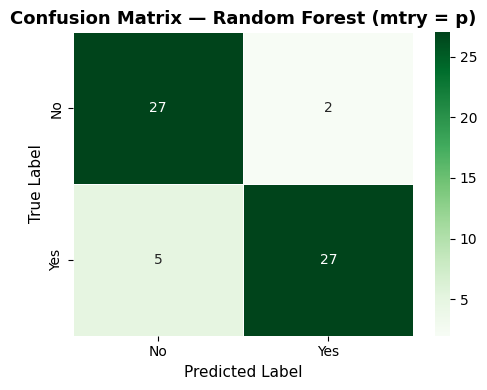

True Negatives  (No  -> No ) : 27
False Positives (No  -> Yes) : 2
False Negatives (Yes -> No ) : 5
True Positives  (Yes -> Yes) : 27

Overall Accuracy            : 0.8852


In [80]:
# --- Confusion Matrix Heatmap — Random Forest ---
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_test_enc, y_pred_rf)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.5,
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Confusion Matrix — Random Forest (mtry = p)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f'True Negatives  (No  -> No ) : {tn}')
print(f'False Positives (No  -> Yes) : {fp}')
print(f'False Negatives (Yes -> No ) : {fn}')
print(f'True Positives  (Yes -> Yes) : {tp}')
print(f'\nOverall Accuracy            : {accuracy_score(y_test_enc, y_pred_rf):.4f}')

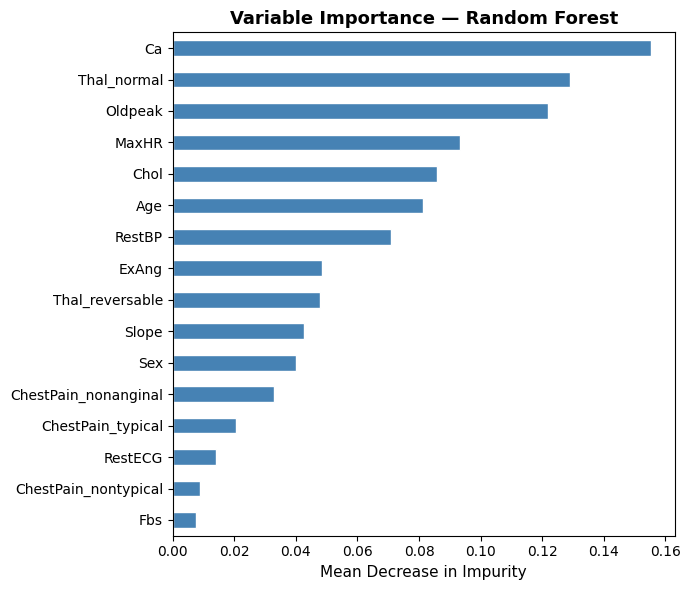

In [81]:
# --- Feature Importance (Mean Decrease in Impurity) ---
import pandas as pd

importances = pd.Series(
    rf.feature_importances_,
    index=X_train_enc.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 6))
importances.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity', fontsize=11)
ax.set_title('Variable Importance — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Random Forest — `mtry = sqrt(p)`
Using a random subset of `sqrt(p)` features at each split (the standard default for classification).

In [82]:
# --- Random Forest with mtry = sqrt(p) ---
import math

mtry_sqrt = math.floor(math.sqrt(X_train_enc.shape[1]))
print(f'Total predictors p = {X_train_enc.shape[1]},  mtry = sqrt(p) = {mtry_sqrt}')

rf_sqrt = RandomForestClassifier(
    n_estimators=500,
    max_features=mtry_sqrt,
    random_state=42
)
rf_sqrt.fit(X_train_enc, y_train_enc)

y_pred_rf2      = rf_sqrt.predict(X_test_enc)
y_prob_rf2      = rf_sqrt.predict_proba(X_test_enc)[:, 1]

print(f'\nRandom Forest (sqrt-mtry) Accuracy : {accuracy_score(y_test_enc, y_pred_rf2):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test_enc, y_pred_rf2, target_names=le.classes_))

Total predictors p = 16,  mtry = sqrt(p) = 4

Random Forest (sqrt-mtry) Accuracy : 0.8852

Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.93      0.89        29
         Yes       0.93      0.84      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



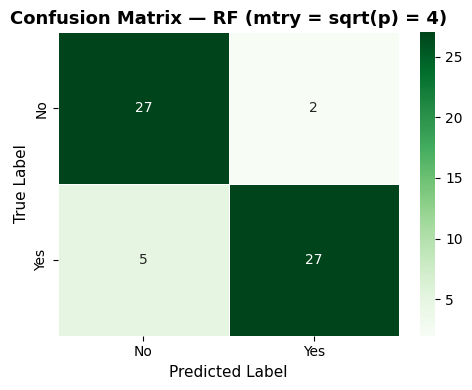

In [83]:
# --- Confusion Matrix — RF sqrt(p) ---
cm_rf2 = confusion_matrix(y_test_enc, y_pred_rf2)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_rf2, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title(f'Confusion Matrix — RF (mtry = sqrt(p) = {mtry_sqrt})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Gradient Boosting (GBM)
Using `GradientBoostingClassifier` — the Python equivalent of R's `gbm()`.  
The target `y_train_enc` is already numeric (Yes = 1, No = 0) from the earlier `LabelEncoder` step.

In [84]:
# --- GBM fit ---
# y_train_enc / y_test_enc are already numeric: No=0, Yes=1
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.5,          # stochastic GBM (bag.fraction in R gbm)
    random_state=42
)
gbm.fit(X_train_enc, y_train_enc)

# Predicted probabilities -> class labels at 0.5 threshold
y_prob_gbm = gbm.predict_proba(X_test_enc)[:, 1]
y_pred_gbm = (y_prob_gbm >= 0.5).astype(int)

print(f'GBM Accuracy : {accuracy_score(y_test_enc, y_pred_gbm):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test_enc, y_pred_gbm, target_names=le.classes_))

GBM Accuracy : 0.8689

Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.90      0.87        29
         Yes       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



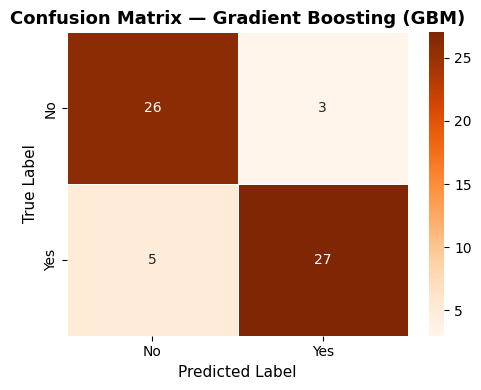

In [85]:
# --- Confusion Matrix — GBM ---
cm_gbm = confusion_matrix(y_test_enc, y_pred_gbm)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_gbm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Confusion Matrix — Gradient Boosting (GBM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Model Comparison
Compare all four models on the test set: **Accuracy, Sensitivity (Recall for Yes), Specificity, and AUC**.

In [86]:
# --- Model Comparison: Accuracy / Sensitivity / Specificity / AUC ---
from sklearn.metrics import roc_auc_score

# Collect predicted probabilities for every model
# Logistic Regression
y_prob_lr  = lr.predict_proba(X_test_scaled)[:, 1]
# Decision Tree
y_prob_dt  = dt.predict_proba(X_test_enc)[:, 1]
# RF (mtry = p)
y_prob_rf  = rf.predict_proba(X_test_enc)[:, 1]
# RF (mtry = sqrt(p))  -- y_prob_rf2 already defined above
# GBM                  -- y_prob_gbm already defined above

models = {
    'Logistic Regression' : (y_pred,     y_prob_lr),
    'Decision Tree'       : (y_pred_dt,  y_prob_dt),
    'RF (mtry = p)'       : (y_pred_rf,  y_prob_rf),
    'RF (mtry = sqrt(p))' : (y_pred_rf2, y_prob_rf2),
    'GBM'                 : (y_pred_gbm, y_prob_gbm),
}

rows = []
for name, (y_pred_m, y_prob_m) in models.items():
    cm_m  = confusion_matrix(y_test_enc, y_pred_m)
    tn_m, fp_m, fn_m, tp_m = cm_m.ravel()
    acc   = accuracy_score(y_test_enc, y_pred_m)
    sens  = tp_m / (tp_m + fn_m)          # sensitivity = recall for 'Yes'
    spec  = tn_m / (tn_m + fp_m)          # specificity = recall for 'No'
    auc   = roc_auc_score(y_test_enc, y_prob_m)
    rows.append({'Model': name, 'Accuracy': acc,
                 'Sensitivity': sens, 'Specificity': spec, 'AUC': auc})

results_df = pd.DataFrame(rows).set_index('Model')
print(results_df.round(4).to_string())

                     Accuracy  Sensitivity  Specificity     AUC
Model                                                          
Logistic Regression    0.8689       0.9062       0.8276  0.9364
Decision Tree          0.8033       0.6562       0.9655  0.7947
RF (mtry = p)          0.8852       0.8438       0.9310  0.9256
RF (mtry = sqrt(p))    0.8852       0.8438       0.9310  0.9413
GBM                    0.8689       0.8438       0.8966  0.9310


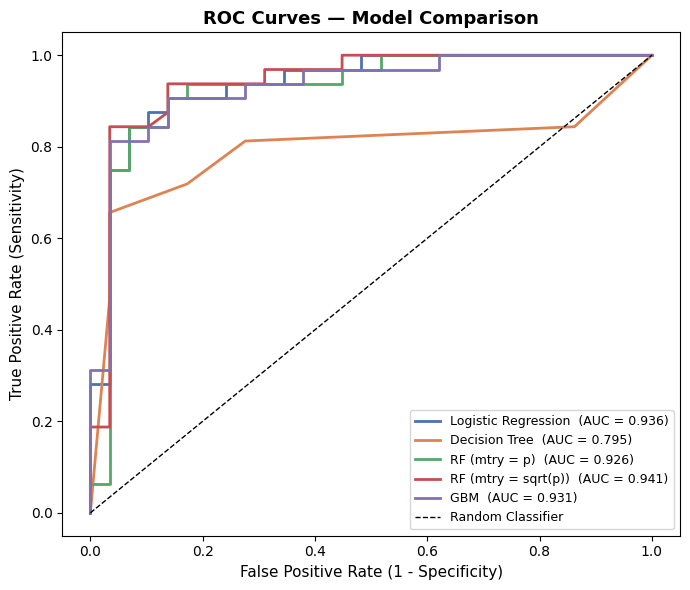

In [87]:
# --- ROC Curves for all models ---
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 6))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
for (name, (y_pred_m, y_prob_m)), col in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test_enc, y_prob_m)
    auc_val = roc_auc_score(y_test_enc, y_prob_m)
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc_val:.3f})', color=col, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

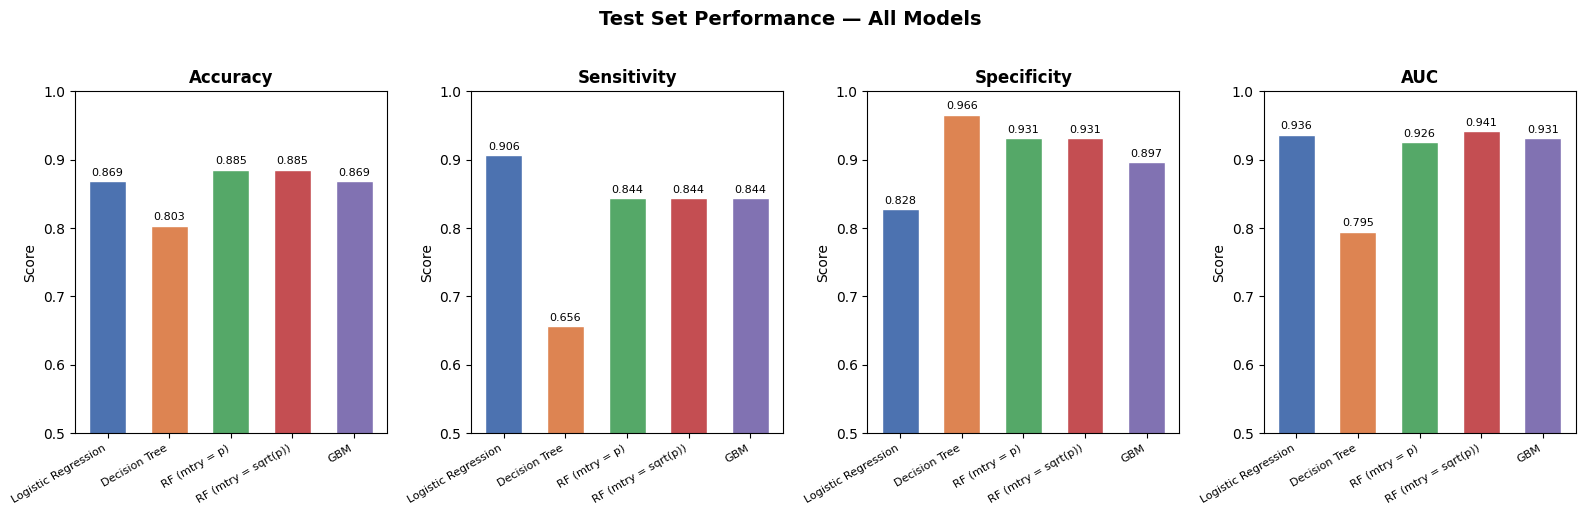

In [88]:
# --- Bar chart comparison of all metrics ---
metrics = ['Accuracy', 'Sensitivity', 'Specificity', 'AUC']

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for ax, metric in zip(axes, metrics):
    vals   = results_df[metric]
    bars   = ax.bar(range(len(vals)), vals.values, color=palette, edgecolor='white', width=0.6)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0.5, 1.0)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Test Set Performance — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()